# Induction Motor Fault Diagnosis - Deep Learning Optimization

This notebook implements advanced Deep Learning models for fault diagnosis, addressing previous limitations:
1.  **Models**:
    *   **Optimized 1D CNN**: Uses Global Average Pooling and Regularization to prevent overfitting on raw signals.
    *   **MLP**: Trained on FFT features.
2.  **Advanced Training**:
    *   **Stratified K-Fold Cross-Validation**: Robust evaluation on the small dataset.
    *   **Cosine Decay Learning Rate**: For better convergence.
3.  **Visualization**:
    *   ROC Curves, t-SNE Feature Projection, and Class-wise Metrics.

## 1. Setup & Imports

In [32]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import joblib
import glob

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.loaders import InductionMotorLoader
from src.models.dl_models import create_1d_cnn, create_mlp

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [33]:
# --- Helper Functions ---

def verify_data_completeness(data_dir):
    """Verifies that all 43 raw files are present and loaded."""
    expected_files = 43 # Based on file listing
    found_files = glob.glob(os.path.join(data_dir, "*.csv"))
    print(f"Found {len(found_files)} CSV files in {data_dir}")
    if len(found_files) < expected_files:
        print("WARNING: Potential missing files!")
    else:
        print("SUCCESS: All expected data files found.")

def plot_multiclass_roc(y_test, y_score, n_classes, class_names, title='ROC Curve'):
    """Plots ROC curves for multiclass classification."""
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # One-hot encode y_test for ROC calculation if it's not already
    y_test_bin = tf.keras.utils.to_categorical(y_test, num_classes=n_classes)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_names[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

def plot_tsne(model, X_data, y_data, class_names, layer_index=-2):
    """Plots t-SNE projection of features from a specific layer."""
    # Create a feature extractor model
    feature_extractor = models.Model(inputs=model.inputs, outputs=model.layers[layer_index].output)
    features = feature_extractor.predict(X_data)
    
    # Compute t-SNE
    n_samples = features.shape[0]
    # Perplexity must be less than n_samples. Default is 30.
    perplexity = min(30, n_samples - 1) if n_samples > 1 else 1
    
    print(f"Computing t-SNE with perplexity={perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(features)
    
    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_data, cmap='viridis', alpha=0.7)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names))
    plt.title(f't-SNE Projection of Features (Layer {layer_index})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()

## 2. Data Loading & Verification

In [34]:
DATA_DIR = r'../Induction_Motor_Data/induction motor data/preprocessing/processed_data/raw'
verify_data_completeness(DATA_DIR)

loader = InductionMotorLoader(DATA_DIR)

# Load Data
print("Loading FFT Data...")
X_fft, y_fft = loader.load_fft_data_for_mlp()
print(f"FFT Data Shape: {X_fft.shape}")

print("Loading Raw Data (Windowed)...")
# Aggressive windowing for CNN
X_raw, y_raw = loader.load_raw_data_for_cnn(window_size=2048, stride=100) 
print(f"Raw Data Shape: {X_raw.shape}")

# Encode Labels
le = LabelEncoder()
y_enc = le.fit_transform(y_fft) 
y_raw_enc = le.transform(y_raw) # Encode raw labels using the same encoder

num_classes = len(np.unique(y_enc))
class_names = le.classes_.astype(str)

Found 43 CSV files in ../Induction_Motor_Data/induction motor data/preprocessing/processed_data/raw
SUCCESS: All expected data files found.
Loading FFT Data...
Loaded damaged_1 FFT features: (9, 255)
Loaded damaged_2 FFT features: (10, 255)
Loaded damaged_ring FFT features: (12, 255)
Loaded healthy FFT features: (9, 255)
FFT Data Shape: (40, 255)
Loading Raw Data (Windowed)...
Raw Data Shape: (305, 2048, 1)


## 3. Stratified K-Fold Cross-Validation (The Gold Standard)
We will evaluate the CNN and MLP using 5-fold CV to get a reliable accuracy estimate.

In [35]:
def train_evaluate_kfold(model_type, X, y, n_splits=5):
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_accuracies = []
    
    print(f"\nStarting {n_splits}-Fold CV for {model_type}...")
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"Fold {fold+1}/{n_splits}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Scaling (Important for MLP, less so for Raw CNN but good practice)
        if model_type == 'MLP':
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
        elif model_type == 'CNN':
             # Simple standardization for raw signals
            mean = np.mean(X_train)
            std = np.std(X_train)
            X_train = (X_train - mean) / (std + 1e-9)
            X_val = (X_val - mean) / (std + 1e-9)

        # Create Model
        if model_type == 'MLP':
            model = create_mlp(input_shape=(X_train.shape[1],), num_classes=num_classes)
        else:
            model = create_1d_cnn(input_shape=(X_train.shape[1], 1), num_classes=num_classes)
            
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        # Callbacks
        lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        
        # Train
        model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), 
                  callbacks=[lr_scheduler, early_stopping], verbose=0)
        
        # Evaluate
        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accuracies.append(acc)
        print(f"  Accuracy: {acc:.4f}")
        
    print(f"\n{model_type} Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
    return fold_accuracies

# Run CV
mlp_scores = train_evaluate_kfold('MLP', X_fft, y_enc)
cnn_scores = train_evaluate_kfold('CNN', X_raw, y_raw_enc)


Starting 5-Fold CV for MLP...
Fold 1/5
  Accuracy: 0.3750
Fold 2/5
  Accuracy: 0.6250
Fold 3/5
  Accuracy: 0.1250
Fold 4/5
  Accuracy: 0.2500
Fold 5/5
  Accuracy: 0.2500

MLP Average Accuracy: 0.3250 (+/- 0.1696)

Starting 5-Fold CV for CNN...
Fold 1/5
  Accuracy: 0.3934
Fold 2/5
  Accuracy: 0.3770
Fold 3/5
  Accuracy: 0.4590
Fold 4/5
  Accuracy: 0.5246
Fold 5/5
  Accuracy: 0.5246

CNN Average Accuracy: 0.4557 (+/- 0.0626)


## 4. Final Training & Visualization (Train/Test Split)
We train on a 80/20 split to generate the final plots and models.

In [36]:
print("\n--- Final Training for Visualization ---")

# --- MLP Split ---
X_train_fft, X_test_fft, y_train_fft, y_test_fft = train_test_split(
    X_fft, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# --- CNN Split ---
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw_enc, test_size=0.2, random_state=42, stratify=y_raw_enc
)

# --- Scaling ---
scaler_mlp = StandardScaler()
X_train_fft = scaler_mlp.fit_transform(X_train_fft)
X_test_fft = scaler_mlp.transform(X_test_fft)

mean_raw = np.mean(X_train_raw)
std_raw = np.std(X_train_raw)
X_train_raw = (X_train_raw - mean_raw) / (std_raw + 1e-9)
X_test_raw = (X_test_raw - mean_raw) / (std_raw + 1e-9)

# --- Train MLP ---
print("Training Final MLP...")
mlp_final = create_mlp((X_train_fft.shape[1],), num_classes)
mlp_final.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp_final.fit(X_train_fft, y_train_fft, epochs=50, batch_size=32, verbose=0, callbacks=[callbacks.EarlyStopping(patience=10)])

# --- Train CNN ---
print("Training Final CNN...")
cnn_final = create_1d_cnn((X_train_raw.shape[1], 1), num_classes)
cnn_final.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_final.fit(X_train_raw, y_train_raw, epochs=50, batch_size=64, verbose=0, callbacks=[callbacks.EarlyStopping(patience=10)])

# --- Predictions ---
y_pred_mlp = mlp_final.predict(X_test_fft)
y_pred_class_mlp = np.argmax(y_pred_mlp, axis=1)

y_pred_cnn = cnn_final.predict(X_test_raw)
y_pred_class_cnn = np.argmax(y_pred_cnn, axis=1)

print("\n--- MLP Performance ---")
print(classification_report(y_test_fft, y_pred_class_mlp, target_names=class_names))

print("\n--- CNN Performance ---")
print(classification_report(y_test_raw, y_pred_class_cnn, target_names=class_names))


--- Final Training for Visualization ---
Training Final MLP...


C:\Users\WORKNFLOW\AppData\Roaming\Python\Python313\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Training Final CNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

--- MLP Performance ---
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.20      0.50      0.29         2

    accuracy                           0.25         8
   macro avg       0.13      0.25      0.17         8
weighted avg       0.13      0.25      0.17         8


--- CNN Performance ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.22      0.31      0.26        16
           2       0.00      0.00      0.00        15
           3       0.39      0.71      0.51        21

    accuracy                           0.33        61
   macro avg       0.15      0.26      0.19        61
weighted avg       0.19      0.33  

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine

## 5. Advanced Visualizations

Plotting ROC Curves (MLP)...


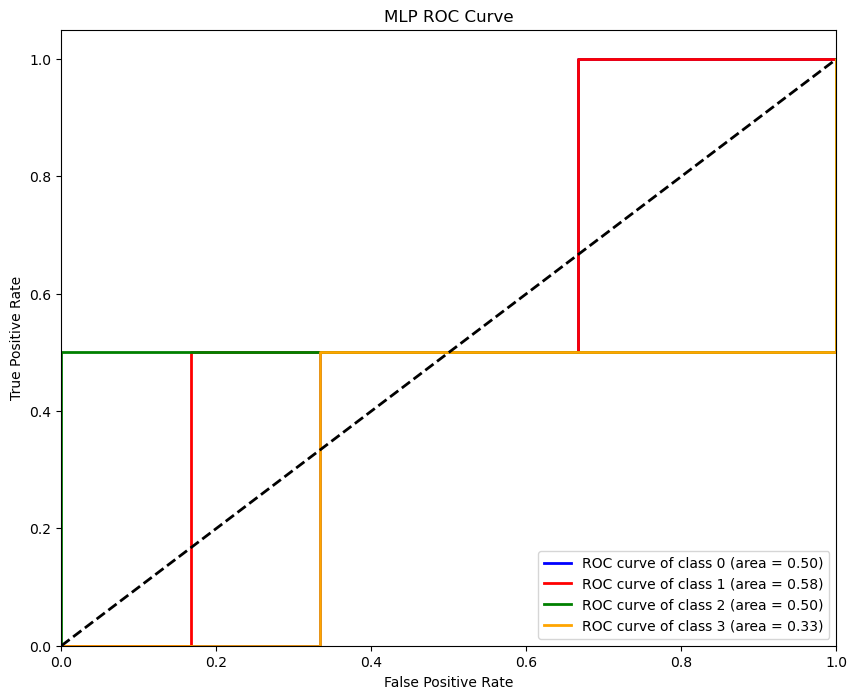

Plotting ROC Curves (CNN)...


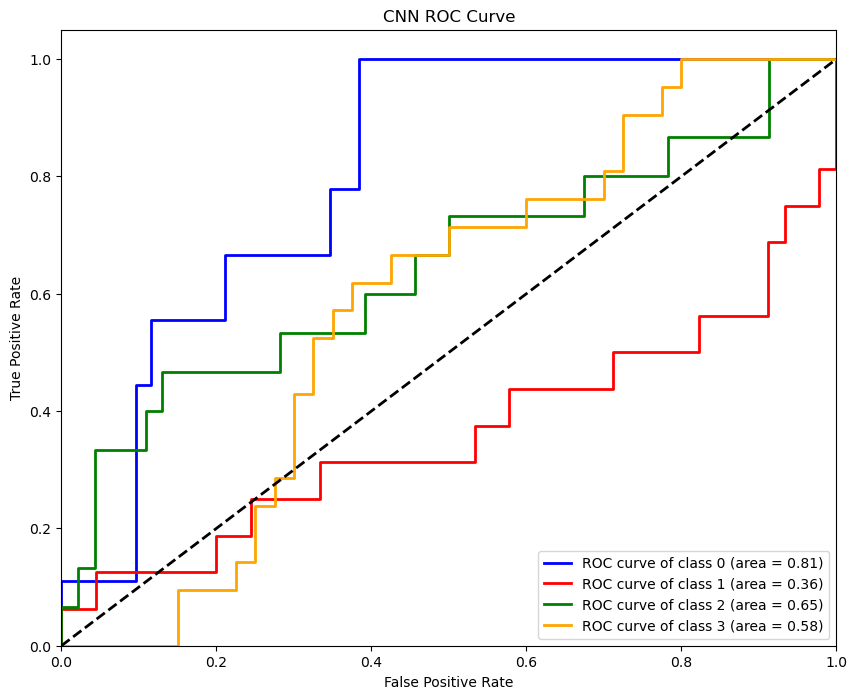

Plotting t-SNE (MLP Features)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Computing t-SNE with perplexity=7...


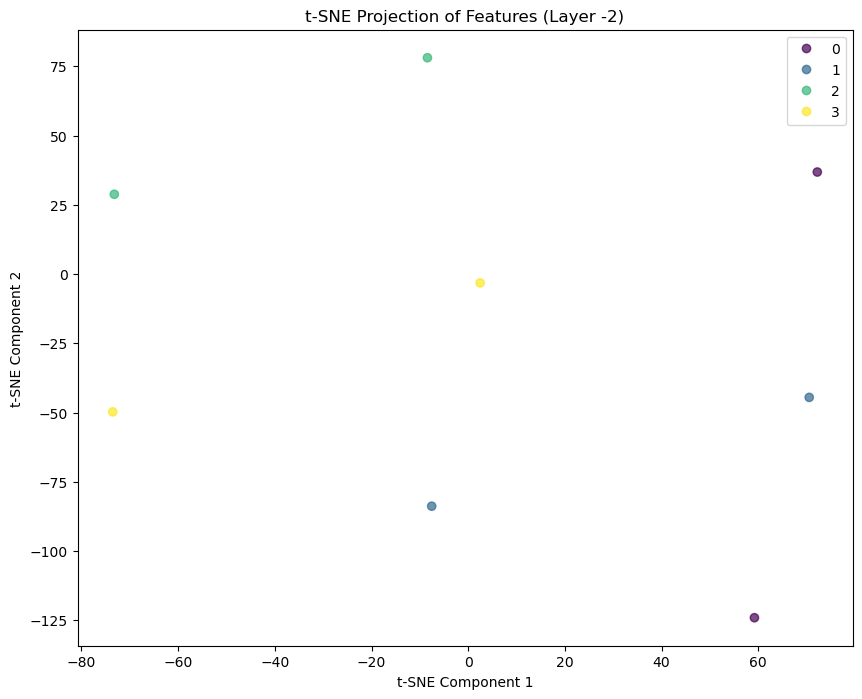

Plotting Confusion Matrix (MLP)...


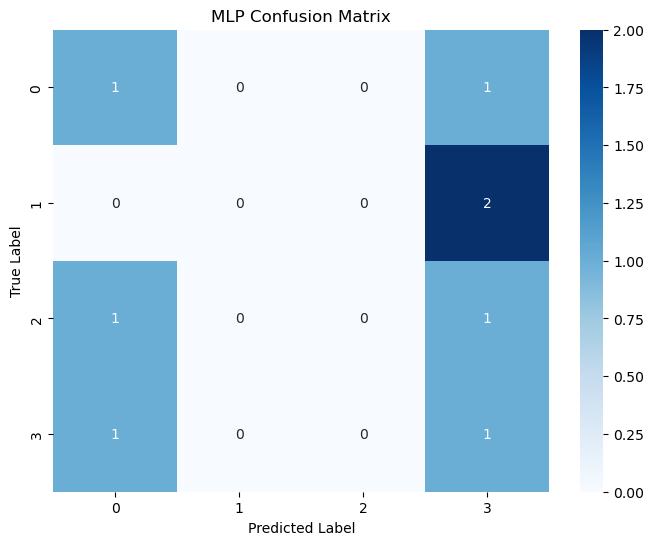

In [37]:
print("Plotting ROC Curves (MLP)...")
plot_multiclass_roc(y_test_fft, y_pred_mlp, num_classes, class_names, title='MLP ROC Curve')

print("Plotting ROC Curves (CNN)...")
plot_multiclass_roc(y_test_raw, y_pred_cnn, num_classes, class_names, title='CNN ROC Curve')

print("Plotting t-SNE (MLP Features)...")
plot_tsne(mlp_final, X_test_fft, y_test_fft, class_names, layer_index=-2)

print("Plotting Confusion Matrix (MLP)...")
cm = confusion_matrix(y_test_fft, y_pred_class_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('MLP Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [38]:
# Save Final Models
save_dir = r'../Trained_models/induction_dl_optimized'
os.makedirs(save_dir, exist_ok=True)
mlp_final.save(os.path.join(save_dir, 'mlp_optimized.keras'))
cnn_final.save(os.path.join(save_dir, 'cnn_optimized.keras'))
joblib.dump(scaler_mlp, os.path.join(save_dir, 'mlp_scaler.pkl'))
print(f"Models saved to {save_dir}")

Models saved to ../Trained_models/induction_dl_optimized
